# Phase 4 — Modélisation

Objectif : prédire le nombre de réactions d'un post avant publication, à partir des
911 variables construites en phase 3.

## Protocole

| | |
|---|---|
| Cible | `log_interactions = log(1 + likes + commentaires)` |
| Entraînement | 2 651 posts / 21 comptes |
| Validation | 936 posts / 7 comptes |
| Variables | 911 (15 tabulaires, 384 texte, 512 image) |

**Le découpage est fait par compte**, jamais par post : deux publications d'un même
compte partagent son audience et son style.

**Le réglage des hyperparamètres n'utilise jamais la validation.** Il passe par une
validation croisée `GroupKFold` à l'intérieur du train, groupée par compte. Régler sur
la validation puis y mesurer la performance donnerait un score optimiste.

## Comment lire les erreurs

L'erreur est mesurée en échelle logarithmique, celle de la cible. Pour l'intuition, on
la reconvertit : une erreur absolue moyenne de 1,10 en log signifie que la prédiction
est typiquement fausse **d'un facteur e^1,10 ≈ 3**. Un post qui reçoit 100 réactions
sera prédit entre 33 et 300.

In [1]:
import sys, json
from pathlib import Path

RACINE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RACINE))

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.viz.style import DIVERGENT, INK, appliquer_style, couleurs_theme, finir
from src.models.train_models import charger

MODE = "light"
ink = appliquer_style(MODE)
C_T, DIV = couleurs_theme(MODE), DIVERGENT[MODE]

R = json.loads((RACINE / "data/processed/resultats_modeles.json").read_text(encoding="utf-8"))
u, colonnes, tr, va = charger()
print(f"{R['train']['posts']} posts train / {R['validation']['posts']} validation"
      f"  |  {R['n_variables']} variables  |  seeds {R['seeds']}")

2651 posts train / 936 validation  |  911 variables  |  seeds [0, 1, 2, 3, 4]


---
## 1. Les deux baselines à battre

Avant tout modèle, il faut savoir ce que vaut la solution triviale. Sans ce repère,
n'importe quel score paraît acceptable.

- **Médiane du train** : prédire la même valeur pour tous les posts, en ignorant
  totalement leur contenu.
- **Régression sur les abonnés** : une droite sur la seule variable `followers`.

In [2]:
base = pd.DataFrame(R["baselines"]).T[["rmse_log", "mae_log", "facteur_erreur",
                                       "mediane_erreur_interactions"]]
base.columns = ["RMSE (log)", "MAE (log)", "facteur d'erreur", "erreur mediane (reactions)"]
print(base.round(3).to_string())

                          RMSE (log)  MAE (log)  facteur d'erreur  erreur mediane (reactions)
Mediane du train               1.402      1.141             3.131                      90.500
Regression sur followers       1.362      1.109             3.033                      94.397


Le repère est posé : **RMSE 1,402 pour la médiane, 1,362 pour la régression sur les
abonnés.** Connaître le seul nombre d'abonnés fait déjà mieux que ne rien savoir, ce
qui est cohérent avec la phase 2.

---
## 2. Trois candidats, cinq graines

Chaque modèle est entraîné cinq fois avec des graines différentes. Un modèle dont le
score varie beaucoup d'une graine à l'autre n'est pas fiable, même si sa meilleure
valeur est bonne.

In [3]:
lignes = []
for nom, m in R["candidats"].items():
    lignes.append({"modele": nom,
                   "RMSE moyen": m["rmse_log"]["moyenne"],
                   "ecart-type": m["rmse_log"]["ecart_type"],
                   "MAE moyen": m["mae_log"]["moyenne"],
                   "facteur d'erreur": m["facteur_erreur"]["moyenne"]})
cand = pd.DataFrame(lignes).set_index("modele").sort_values("RMSE moyen")
print(cand.round(4).to_string())

              RMSE moyen  ecart-type  MAE moyen  facteur d'erreur
modele                                                           
LightGBM          1.4043      0.0152     1.1423            3.1344
XGBoost           1.4186      0.0096     1.1641            3.2033
RandomForest      1.4244      0.0048     1.1793            3.2522


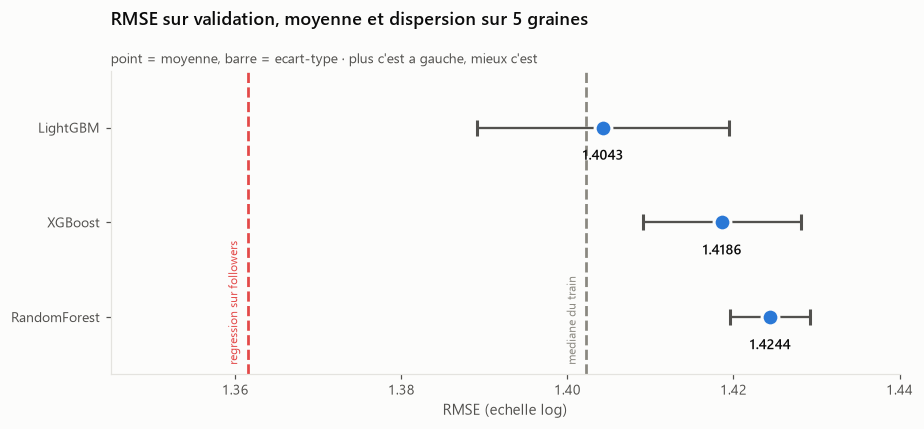

In [4]:
noms = list(cand.index)
fig, ax = plt.subplots(figsize=(8.5, 4))
y = np.arange(len(noms))

# Points et non barres : les ecarts sont minimes et une barre tronquee a 1,30
# les exagererait visuellement.
ax.errorbar(cand["RMSE moyen"], y, xerr=cand["ecart-type"], fmt="o", markersize=11,
            color=C_T["art"], markeredgecolor=ink["surface"], markeredgewidth=2,
            ecolor=ink["secondary"], elinewidth=1.5, capsize=5, zorder=3)

for cle, couleur, libelle in [("Mediane du train", ink["muted"], "mediane du train"),
                              ("Regression sur followers", DIV["neg"], "regression sur followers")]:
    v = R["baselines"][cle]["rmse_log"]
    ax.axvline(v, color=couleur, linestyle="--", linewidth=1.8, zorder=2)
    ax.annotate(libelle, xy=(v, 0.03), xycoords=("data", "axes fraction"),
                xytext=(-5, 0), textcoords="offset points", rotation=90,
                fontsize=8, color=couleur, ha="right", va="bottom")

for i, v in enumerate(cand["RMSE moyen"]):
    ax.annotate(f"{v:.4f}", (v, i), xytext=(0, -21), textcoords="offset points",
                ha="center", fontsize=9, color=ink["primary"], fontweight="semibold")

ax.set_yticks(y); ax.set_yticklabels(noms)
ax.set_ylim(-0.6, len(noms) - 0.4)
ax.invert_yaxis()
ax.set_xlim(1.345, 1.44)
ax.grid(axis="y", visible=False)
finir(ax, "RMSE sur validation, moyenne et dispersion sur 5 graines",
      "point = moyenne, barre = ecart-type · plus c'est a gauche, mieux c'est",
      None, "RMSE (echelle log)", MODE)
plt.tight_layout(); plt.show()

Les trois candidats se tiennent dans un mouchoir de poche, entre 1,404 et 1,424.
LightGBM est en tête mais c'est aussi le plus instable (écart-type 0,0152 contre 0,0048
pour RandomForest).

Plus gênant : **aucun des trois ne bat la régression sur les abonnés seuls** (trait
rouge, 1,362). Trois algorithmes réputés, 911 variables, et le résultat reste derrière
une droite ajustée sur un seul nombre.

                   posts     mae       sse  part_erreur_totale
vj_on_trails       170.0  1.0931  346.7702              0.1911
softlyemy          152.0  1.1593  345.6554              0.1905
jessicamills_art   200.0  1.1756  311.9490              0.1719
basta_sia_outdoor  200.0  1.1299  297.7669              0.1641
yaraa.writings      83.0  1.2447  214.8280              0.1184
kifaya.shadi        24.0  2.2190  198.2623              0.1093
imehdi_nasiri      107.0  0.7924   99.4734              0.0548


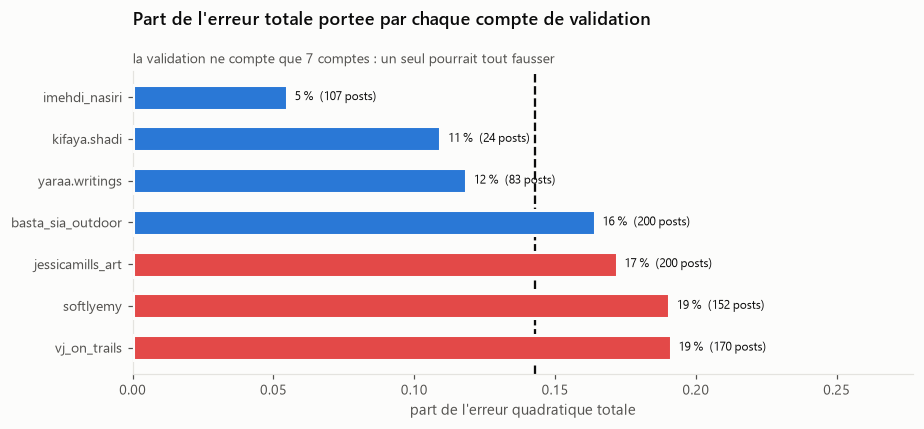

In [5]:
par_compte = pd.DataFrame(R["erreur_par_compte"]["LightGBM"]).T.sort_values(
    "part_erreur_totale", ascending=False)
print(par_compte.to_string())

fig, ax = plt.subplots(figsize=(8.5, 4))
y = np.arange(len(par_compte))
part = par_compte.part_erreur_totale.values
equilibre = 1 / len(par_compte)
ax.barh(y, part, height=0.6, color=[DIV["neg"] if p > equilibre * 1.15 else C_T["art"]
                                   for p in part],
        edgecolor=ink["surface"], linewidth=2, zorder=3)
ax.axvline(equilibre, color=ink["primary"], linestyle="--", linewidth=1.5)
ax.annotate("repartition parfaitement egale", (equilibre, -0.7), fontsize=8,
            color=ink["secondary"], ha="center")
for i, (p, n) in enumerate(zip(part, par_compte.posts)):
    ax.annotate(f"{p * 100:.0f} %  ({int(n)} posts)", (p, i), xytext=(5, 0),
                textcoords="offset points", va="center", fontsize=8, color=ink["primary"])
ax.set_yticks(y); ax.set_yticklabels(par_compte.index, fontsize=9)
ax.set_xlim(0, part.max() * 1.45)
ax.grid(axis="y", visible=False)
finir(ax, "Part de l'erreur totale portee par chaque compte de validation",
      "la validation ne compte que 7 comptes : un seul pourrait tout fausser",
      None, "part de l'erreur quadratique totale", MODE)
plt.tight_layout(); plt.show()

**Bonne nouvelle : aucun compte ne domine l'erreur.** Avec 7 comptes, une répartition
parfaitement égale donnerait 14,3 % chacun ; le maximum observé est 19,1 %. Le score
agrégé n'est donc pas l'artefact d'un seul compte aberrant.

Un cas mérite l'œil : `kifaya.shadi` a de loin la pire erreur moyenne (2,22 contre 0,79
à 1,25 pour les autres) mais ne pèse que 10,9 % du total, car il n'a que 24 posts. Son
contenu est mal prédit, sans que cela contamine le résultat d'ensemble.

---
## 3. Sélection et réglage

LightGBM est retenu : meilleur RMSE moyen, et son instabilité supplémentaire
(±0,015) reste inférieure à l'écart qui le sépare des deux autres. Le critère utilisé
est `RMSE moyen + écart-type`, qui pénalise l'instabilité plutôt que de récompenser
la meilleure graine.

Le réglage explore 18 combinaisons tirées au hasard, évaluées par validation croisée
groupée par compte à l'intérieur du train.

In [6]:
essais = pd.DataFrame([{**e["params"], "rmse_cv": e["rmse_cv"]} for e in R["tuning"]["essais"]])
print("5 meilleures combinaisons :")
print(essais.nsmallest(5, "rmse_cv")[
    ["n_estimators", "num_leaves", "learning_rate", "min_child_samples", "rmse_cv"]
].to_string(index=False))

f = R["modele_final"]
print(f"\nModele final sur validation :")
print(f"  RMSE {f['rmse_log']:.4f} | MAE {f['mae_log']:.4f}")
print(f"  soit un facteur d'erreur de {f['facteur_erreur']:.2f}x")
print(f"  erreur mediane : {f['mediane_erreur_interactions']:.0f} reactions")

5 meilleures combinaisons :
 n_estimators  num_leaves  learning_rate  min_child_samples  rmse_cv
          300          15           0.02                 10 1.746267
          500          15           0.02                 10 1.752163
          800          15           0.05                 40 1.763444
          500          31           0.05                 40 1.767757
          300          63           0.05                 40 1.772364

Modele final sur validation :
  RMSE 1.3678 | MAE 1.1085
  soit un facteur d'erreur de 3.03x
  erreur mediane : 99 reactions


Le réglage fait passer le RMSE de 1,404 à **1,368**. Un gain réel mais modeste, qui ne
change pas le diagnostic.

À noter : le RMSE en validation croisée (environ 1,75) est bien plus élevé que sur la
validation finale (1,368). Ce n'est pas une erreur : la validation croisée groupée par
compte crée des découpages plus difficiles que le découpage train/validation retenu.
Elle sert à *comparer* des configurations entre elles, pas à prédire le score final.

---
## 4. Le résultat gênant

Mettons les chiffres côte à côte.

In [7]:
recap = pd.DataFrame({
    "Mediane du train": R["baselines"]["Mediane du train"],
    "Regression sur followers": R["baselines"]["Regression sur followers"],
    "LightGBM par defaut": {k: v["moyenne"] for k, v in R["candidats"]["LightGBM"].items()},
    "LightGBM regle": R["modele_final"],
}).T[["rmse_log", "mae_log", "facteur_erreur"]]
recap.columns = ["RMSE (log)", "MAE (log)", "facteur d'erreur"]
recap["gain vs mediane"] = (1 - recap["RMSE (log)"] / recap.loc["Mediane du train", "RMSE (log)"]) * 100
print(recap.round(3).to_string())

                          RMSE (log)  MAE (log)  facteur d'erreur  gain vs mediane
Mediane du train               1.402      1.141             3.131            0.000
Regression sur followers       1.362      1.109             3.033            2.903
LightGBM par defaut            1.404      1.142             3.134           -0.148
LightGBM regle                 1.368      1.108             3.030            2.454


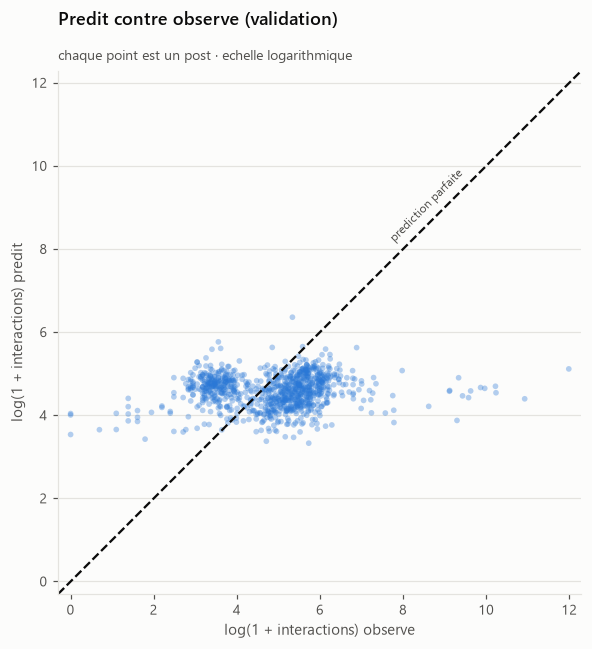

etendue des valeurs observees : 0.0 a 12.0
etendue des predictions       : 3.3 a 6.4
ecart-type observe 1.32 contre 0.39 pour les predictions


In [8]:
b = joblib.load(RACINE / "models/modele_final.joblib")
pred = b["modele"].predict(u.loc[va, colonnes])
vrai = u.log_interactions[va].values

fig, ax = plt.subplots(figsize=(6.4, 6))
ax.scatter(vrai, pred, s=14, alpha=0.35, color=C_T["art"], edgecolor="none")
lim = [min(vrai.min(), pred.min()) - 0.3, max(vrai.max(), pred.max()) + 0.3]
ax.plot(lim, lim, color=ink["primary"], linestyle="--", linewidth=1.5)
milieu = lim[0] + 0.72 * (lim[1] - lim[0])
ax.annotate("prediction parfaite", (milieu, milieu), xytext=(-4, 6),
            textcoords="offset points", rotation=45, rotation_mode="anchor",
            fontsize=8, color=ink["secondary"], ha="center")
ax.set_xlim(lim); ax.set_ylim(lim); ax.set_aspect("equal")
finir(ax, "Predit contre observe (validation)",
      "chaque point est un post · echelle logarithmique",
      "log(1 + interactions) predit", "log(1 + interactions) observe", MODE)
plt.tight_layout(); plt.show()

print(f"etendue des valeurs observees : {vrai.min():.1f} a {vrai.max():.1f}")
print(f"etendue des predictions       : {pred.min():.1f} a {pred.max():.1f}")
print(f"ecart-type observe {vrai.std():.2f} contre {pred.std():.2f} pour les predictions")

Le nuage raconte tout : **les prédictions sont beaucoup plus resserrées que la
réalité.** Le modèle a appris à prédire des valeurs proches de la moyenne et n'ose
presque jamais s'engager sur un succès ou un échec, ce qui est le comportement typique
d'un modèle qui ne trouve pas de signal exploitable.

C'est un **résultat négatif**, et il vaut la peine d'être énoncé clairement plutôt que
maquillé : avec ces données et ces variables, on ne prédit pas utilement le nombre de
réactions d'un post. Les sections suivantes cherchent pourquoi.

---
## 5. Ablation : d'où vient le signal ?

896 des 911 variables sont des embeddings. Apportent-ils vraiment quelque chose ? On
réentraîne le modèle réglé sur chaque sous-ensemble.

                   n_variables  rmse_log  mae_log
tabulaire seul            15.0    1.5332   1.2949
tabulaire + texte        399.0    1.3654   1.0978
tabulaire + image        527.0    1.4186   1.1769
tout                     911.0    1.3678   1.1085


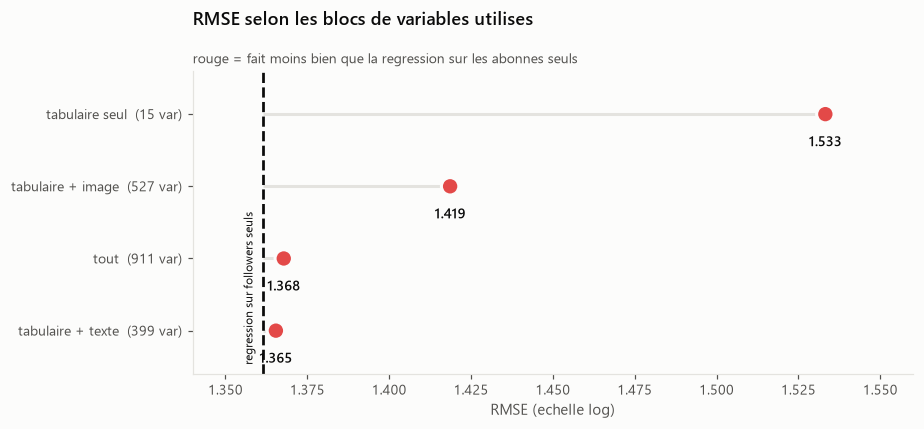

In [9]:
abl = pd.DataFrame(R["ablation"]).T[["n_variables", "rmse_log", "mae_log"]]
print(abl.round(4).to_string())

ordre = ["tabulaire seul", "tabulaire + image", "tout", "tabulaire + texte"]
vals = [R["ablation"][k]["rmse_log"] for k in ordre]
ref = R["baselines"]["Regression sur followers"]["rmse_log"]

fig, ax = plt.subplots(figsize=(8.5, 4))
y = np.arange(len(ordre))
ax.hlines(y, ref, vals, color=ink["grid"], linewidth=2, zorder=2)
ax.scatter(vals, y, s=130, zorder=3,
           color=[DIV["neg"] if v > ref else C_T["art"] for v in vals],
           edgecolor=ink["surface"], linewidth=2)
ax.axvline(ref, color=ink["primary"], linestyle="--", linewidth=1.8, zorder=2)
ax.annotate("regression sur followers seuls", xy=(ref, 0.03),
            xycoords=("data", "axes fraction"), xytext=(-5, 0), rotation=90,
            textcoords="offset points", fontsize=8, color=ink["primary"],
            ha="right", va="bottom")
for i, v in enumerate(vals):
    ax.annotate(f"{v:.3f}", (v, i), xytext=(0, -21), textcoords="offset points",
                ha="center", fontsize=9, color=ink["primary"], fontweight="semibold")

ax.set_yticks(y)
ax.set_yticklabels([f"{k}  ({R['ablation'][k]['n_variables']} var)" for k in ordre],
                   fontsize=9)
ax.set_ylim(-0.6, len(ordre) - 0.4)
ax.invert_yaxis()
ax.set_xlim(1.34, 1.56)
ax.grid(axis="y", visible=False)
finir(ax, "RMSE selon les blocs de variables utilises",
      "rouge = fait moins bien que la regression sur les abonnes seuls",
      None, "RMSE (echelle log)", MODE)
plt.tight_layout(); plt.show()

Trois enseignements, dont un franchement inattendu.

**1. Les 15 variables tabulaires seules font pire que la médiane** (1,533 contre 1,402).
Heure, format, thème, hashtags, abonnés : pris ensemble dans un modèle d'arbres, ils
dégradent la prédiction au lieu de l'améliorer. Avec seulement 21 comptes
d'entraînement, le modèle mémorise des régularités propres à ces comptes qui ne se
transposent pas aux 7 comptes de validation.

**2. Les embeddings de texte sont le seul apport net** : 1,533 → 1,365. C'est le
meilleur score de toute l'étude, et il reste malgré tout au niveau de la régression sur
les abonnés seuls (1,362).

**3. Les embeddings d'image n'apportent rien, et nuisent en présence du texte.**
Seuls, ils font passer de 1,533 à 1,419 ; ajoutés au texte, ils dégradent le score
(1,365 → 1,368). C'est cohérent avec la limite connue : 56 % du jeu est composé de
reels dont on ne voit qu'une miniature figée.

---
## 6. Échantillon complet ou petits comptes seulement ?

Le projet vise les comptes à faible audience. Faut-il entraîner le modèle uniquement
sur eux, quitte à disposer de moins de données ?

Les deux modèles sont évalués **sur le même sous-ensemble de validation**, les seuls
posts de comptes sous 2 000 abonnés.

In [10]:
p = R["petits_comptes"]
print(f"train complet   : {p['posts_train_complet']} posts")
print(f"train restreint : {p['posts_train_restreint']} posts / {p['comptes_train_restreint']} comptes")
print(f"validation      : {p['posts_validation_petits']} posts / {p['comptes_validation_petits']} comptes\n")

cmp = pd.DataFrame({"entraine sur tout": p["modele_complet"],
                    "entraine sur les petits comptes": p["modele_restreint"]}).T
print(cmp[["rmse_log", "mae_log", "facteur_erreur"]].round(4).to_string())

train complet   : 2651 posts
train restreint : 912 posts / 6 comptes
validation      : 360 posts / 3 comptes

                                 rmse_log  mae_log  facteur_erreur
entraine sur tout                  1.3481   1.0457          2.8454
entraine sur les petits comptes    1.4715   1.2019          3.3265


**Le modèle entraîné sur tout l'échantillon généralise mieux** (RMSE 1,348 contre
1,472), y compris sur le terrain des petits comptes.

L'explication tient au volume : restreindre l'entraînement fait tomber de 2 651 à 912
posts et de 21 à 6 comptes. La spécialisation au domaine visé ne compense pas cette
perte. Un modèle qui n'a vu que six comptes apprend surtout les particularités de ces
six-là.

**Cette conclusion est fragile et doit être lue comme provisoire** : la validation ne
comporte que **3 comptes** sous 2 000 abonnés. Le sens du résultat est clair, son
ampleur ne l'est pas. C'est un argument de plus pour collecter davantage de petits
comptes avant de trancher.

---
## 7. Interprétabilité, et une anomalie à élucider

La phase 2 avait mesuré des effets réels. On vérifie qu'ils se retrouvent dans le
modèle — et on prend au sérieux ce qui n'y est pas.

In [11]:
bloc = pd.Series(R["importances"]["par_bloc"]).sort_values(ascending=False)
print("Importance native (gain), par bloc :")
print((bloc * 100).round(1).astype(str).add(" %").to_string())

Importance native (gain), par bloc :
image (embeddings)             40.2 %
texte (embeddings)             33.1 %
followers_z                    21.0 %
jours_depuis_dernier_post_z     3.0 %
theme                           1.9 %
format                          0.6 %
hashtags_tranche                0.1 %
heure_cos                       0.0 %
heure_sin                       0.0 %
caption_vide                    0.0 %
image_manquante                 0.0 %


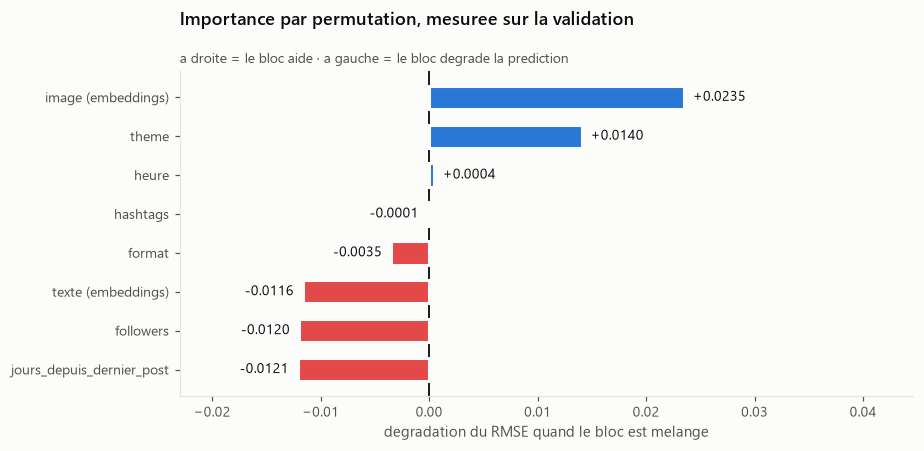

In [12]:
perm = {k: v["degradation_rmse"] for k, v in R["importance_permutation"].items()
        if k != "rmse_reference"}
s = pd.Series(perm).sort_values()

fig, ax = plt.subplots(figsize=(8.5, 4.2))
y = np.arange(len(s))
ax.barh(y, s.values, height=0.6,
        color=[DIV["pos"] if v > 0 else DIV["neg"] for v in s.values],
        edgecolor=ink["surface"], linewidth=2, zorder=3)
ax.axvline(0, color=ink["primary"], linewidth=1.2)
for i, v in enumerate(s.values):
    ax.annotate(f"{v:+.4f}", (v, i), xytext=(6 if v >= 0 else -6, 0),
                textcoords="offset points", va="center",
                ha="left" if v >= 0 else "right", fontsize=9, color=ink["primary"])
ax.set_yticks(y); ax.set_yticklabels(s.index, fontsize=9)
ax.set_xlim(s.min() * 1.9, s.max() * 1.9)
ax.grid(axis="y", visible=False)
finir(ax, "Importance par permutation, mesuree sur la validation",
      "a droite = le bloc aide · a gauche = le bloc degrade la prediction",
      None, "degradation du RMSE quand le bloc est melange", MODE)
plt.tight_layout(); plt.show()

Les deux mesures se contredisent, et c'est le point le plus instructif de la phase.

L'**importance native** attribue 40 % du gain aux images et 33 % au texte. Mais elle ne
mesure que l'usage fait des variables *pendant l'entraînement* : avec 896 dimensions
disponibles, un arbre trouve toujours de quoi découper, même dans du bruit.

L'**importance par permutation**, mesurée sur la validation, répond à la vraie question :
que perd-on en détruisant ce bloc ? Et la réponse est accablante. `followers`, le texte,
le format et l'écart entre publications ont une valeur **négative** : mélanger ces
variables *améliore* la prédiction. Le modèle s'appuie dessus d'une manière qui ne se
transpose pas aux comptes qu'il n'a jamais vus.

Seuls le thème (+0,014) et les images (+0,024) aident réellement, et de façon minime :
moins de 2 % du RMSE.

In [13]:
print("Controle de coherence avec la phase 2 :")
for var, c in R["coherence_phase2"].items():
    print(f"  {var:20} importance={c['importance']:.5f}  {c['statut'].upper():9} ({c['mesure_phase2']})")

v = R["decomposition_variance"]
print(f"\nDecomposition de la variance a predire :")
print(f"  variance totale             : {v['variance_totale']:.3f}")
print(f"  part entre comptes          : {v['part_entre_comptes'] * 100:.0f} %")
print(f"  part expliquee par l'heure  : {v['part_heure_dans_totale'] * 100:.2f} %"
      f"  ({v['part_heure_dans_intra'] * 100:.1f} % de la variance intra-compte)")

Controle de coherence avec la phase 2 :
  followers_z          importance=0.21017  COHERENT  (taille du compte (rho = +0,37))
  heure_sin            importance=0.00028  ANOMALIE  (heure de publication (facteur 1,7))
  heure_cos            importance=0.00033  ANOMALIE  (heure de publication (facteur 1,7))
  hashtags_tranche     importance=0.00104  COHERENT  (hashtags 1-5 (+9 %))

Decomposition de la variance a predire :
  variance totale             : 2.420
  part entre comptes          : 44 %
  part expliquee par l'heure  : 0.58 %  (1.0 % de la variance intra-compte)


### L'anomalie de l'heure, et sa résolution

Le contrôle signale une **anomalie** : `heure_sin` et `heure_cos` ont une importance
quasi nulle (0,0003), alors que la phase 2 avait mesuré un effet net, un facteur 1,7
entre le pire et le meilleur créneau, avec p < 0,001.

Plutôt que d'ignorer la contradiction, mesurons-la. La décomposition de la variance
donne la réponse : **l'heure explique 0,58 % de la variance totale** à prédire, soit
1,0 % de la variance interne aux comptes.

Les deux résultats sont exacts, mais ils ne parlent pas de la même chose :

- La **phase 2** mesurait un décalage de médiane *à l'intérieur* de chaque compte. Sur
  cette échelle relative, +25 % est visible et actionnable pour un créateur.
- Le **modèle** prédit une valeur absolue, dont 44 % de la variance provient de l'écart
  entre comptes et dont l'essentiel du reste est du bruit propre à chaque post. Sur
  cette échelle, un effet à 0,58 % est noyé.

**Ce n'est donc pas un bug, mais une leçon** : un effet peut être statistiquement solide,
pratiquement utile pour un créateur, et malgré tout négligeable pour un modèle de
prédiction. L'ordre de grandeur compte autant que la significativité.

Le même raisonnement vaut pour `hashtags_tranche` : l'effet de +9 % mesuré en phase 2
est réel, et tout aussi marginal à l'échelle de la variance totale.

---
## 8. Récapitulatif

In [14]:
final = pd.DataFrame({
    "Baseline : mediane du train": R["baselines"]["Mediane du train"],
    "Baseline : regression sur followers": R["baselines"]["Regression sur followers"],
    "RandomForest (defaut)": {k: v["moyenne"] for k, v in R["candidats"]["RandomForest"].items()},
    "XGBoost (defaut)": {k: v["moyenne"] for k, v in R["candidats"]["XGBoost"].items()},
    "LightGBM (defaut)": {k: v["moyenne"] for k, v in R["candidats"]["LightGBM"].items()},
    "LightGBM regle": R["modele_final"],
    "LightGBM, texte seul (ablation)": R["ablation"]["tabulaire + texte"],
    "LightGBM restreint < 2000 abonnes": R["petits_comptes"]["modele_restreint"],
}).T

final = final[["rmse_log", "mae_log", "facteur_erreur",
               "mediane_erreur_interactions", "mae_interactions"]]
final.columns = ["RMSE (log)", "MAE (log)", "facteur d'erreur",
                 "erreur mediane (reactions)", "MAE (reactions)"]
print(final.round(2).to_string())

                                     RMSE (log)  MAE (log)  facteur d'erreur  erreur mediane (reactions)  MAE (reactions)
Baseline : mediane du train                1.40       1.14              3.13                       90.50           587.98
Baseline : regression sur followers        1.36       1.11              3.03                       94.40           584.72
RandomForest (defaut)                      1.42       1.18              3.25                       99.65           590.07
XGBoost (defaut)                           1.42       1.16              3.20                      102.63           588.88
LightGBM (defaut)                          1.40       1.14              3.13                      100.74           586.40
LightGBM regle                             1.37       1.11              3.03                       99.14           583.17
LightGBM, texte seul (ablation)            1.37       1.10              3.00                      106.91           581.69
LightGBM restreint < 200

| Modèle | RMSE (log) | Facteur d'erreur | Lecture |
|---|---|---|---|
| Médiane du train | 1,402 | ×3,13 | le repère minimal |
| **Régression sur followers** | **1,362** | **×3,03** | **le meilleur score de l'étude** |
| RandomForest | 1,424 | ×3,25 | |
| XGBoost | 1,419 | ×3,20 | |
| LightGBM | 1,404 | ×3,13 | |
| LightGBM réglé | 1,368 | ×3,03 | 911 variables, à égalité avec une droite |
| LightGBM, texte seul | 1,365 | ×3,02 | meilleure variante, toujours pas devant |
| LightGBM, petits comptes | 1,472 | ×3,33 | moins de données, moins bon |

### Ce qu'il faut retenir

**1. Aucun modèle ne bat une régression linéaire sur le seul nombre d'abonnés.**
911 variables, trois algorithmes, un réglage : le meilleur résultat (1,365) reste au
niveau d'une droite ajustée sur un seul nombre (1,362). C'est le résultat de la phase,
et le maquiller n'aurait aucun intérêt.

**2. L'erreur typique est un facteur 3.** Un post qui obtient 100 réactions est prédit
entre 33 et 300. C'est insuffisant pour décider quoi publier, et il faut le dire avant
de construire une application dessus.

**3. La raison principale est le manque de comptes, pas le manque de posts.**
Le modèle dispose de 2 651 exemples mais de seulement **21 comptes** d'entraînement.
Or 44 % de la variance à prédire se situe *entre* les comptes. Apprendre à généraliser
d'un compte à l'autre sur 21 exemples relève de l'impossible, et l'importance par
permutation le confirme : la plupart des variables dégradent la prédiction sur des
comptes jamais vus.

**4. Les effets de la phase 2 étaient réels mais trop petits pour ce modèle.**
L'heure pèse 0,58 % de la variance, les hashtags à peine plus. Utiles pour conseiller
un créateur, négligeables pour prédire un total.

### Ce que cela change pour la suite

- **Collecter plus de comptes prime sur tout le reste.** Doubler le nombre de posts par
  compte n'aiderait pas ; passer de 21 à 60 comptes, si.
- **L'application de la phase 5 doit annoncer son incertitude** au lieu d'afficher un
  nombre unique. Une fourchette et un rang relatif sont honnêtes ; « ce post fera
  240 réactions » ne l'est pas.
- **Une cible relative au compte serait plus réaliste.** Prédire « ce post fera mieux ou
  moins bien que l'ordinaire de ce compte » élimine les 44 % de variance inter-comptes
  que le modèle ne sait pas traiter, et correspond mieux à la question que se pose un
  créateur.